In [2]:
import torch
import numpy as np

import scipy as sp
from scipy.integrate import solve_ivp
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from PartialObservations.BandFModel import helper_fun

In [3]:
def ode_fun(t, var, par):
    x, y, z, u, v, g = var
    alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = par

    u1_prime = u / ((1+u) * (1+g))
    u2_prime = phi1 * v / (1+v)
    u3_prime = phi2 * v / (sigma + v)

    output = np.zeros(6)
    
    output[0] = -alpha * x + u1_prime * x - uc1_prime * x
    output[1] = -alpha * y + u2_prime * y - uc2_prime * y
    output[2] = -alpha * z + u3_prime * z - uc3_prime * z
    output[3] = alpha * (uf - u) - u1_prime * x
    output[4] = -alpha * v + omega * u1_prime * x - u2_prime * y - sigma * u3_prime * z
    output[5] = -alpha * g + rho * u2_prime * y + eta * u3_prime * z

    return output

def torch_ode_fun(t, var, par):
    x, y, z, u, v, g = var
    alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime = par

    u1_prime = u / ((1+u) * (1+g))
    u2_prime = phi1 * v / (1+v)
    u3_prime = phi2 * v / (sigma + v)

    output = torch.zeros(6)
    
    output[0] = -alpha * x + u1_prime * x - uc1_prime * x
    output[1] = -alpha * y + u2_prime * y - uc2_prime * y
    output[2] = -alpha * z + u3_prime * z - uc3_prime * z
    output[3] = alpha * (uf - u) - u1_prime * x
    output[4] = -alpha * v + omega * u1_prime * x - u2_prime * y - sigma * u3_prime * z
    output[5] = -alpha * g + rho * u2_prime * y + eta * u3_prime * z

    return output



def par_fun(u_m1=0.68, u_m2=0.20, u_m3=0.25, u_c1=0.25, u_c2=0.08, u_c3=0.11,
            K_1=0.01, K_2=0.001, K_3=0.01, K_i=0.01, Y_1=1/2, Y_2=1/1.37, Y_3=1/1.2,
            beta=1.94, gamma=1.8, delta=1.55, D=1/14, sf=1.0):
    
    alpha       =   D / u_m1
    uf          =   sf / K_1
    omega       =   beta * Y_1 * K_1 / K_2
    sigma       =   K_3 / K_2
    rho         =   gamma * Y_2 * K_2 / K_i
    eta         =   delta * Y_3 * K_3 / K_i
    phi1        =   u_m2 / u_m1
    phi2        =   u_m3 / u_m1
    uc1_prime   =   u_c1 / u_m1
    uc2_prime   =   u_c2 / u_m1
    uc3_prime   =   u_c3 / u_m1

    return alpha, uf, omega, sigma, rho, eta, phi1, phi2, uc1_prime, uc2_prime, uc3_prime
    

In [ ]:
from PartialObservations.BandFModel import helper_fun

theta = np.linspace(7.5,8.,20)
t = 0
zero_sol = np.array([1.81343890e+001, 4.58297910e-113, 2.91904989e-001, 2.01315407e+002,
 4.66932196e+002, 6.85662947e-001])
zero_sol = np.array([5.07443675e+01, 1.72061852e-91, 2.00195776e-01, 1.39158972e+02,
 1.07152606e+03, 4.69122154e-01])
output = zero_sol.copy()

stable_ss = []
stable_theta = []

unstable_ss = []
unstable_theta = []

max_vals = []
min_vals = []

nan_arr = np.zeros(6)
nan_arr[:] = np.nan

switch = 0

stable = True

for i in range(len(theta)):
    # zero_sol = zero_sol.copy()
    # zero_sol[zero_sol < 1e-10] = 0.1

    print('Theta')
    print(theta[i])
    mypar = par_fun(D=1/theta[i], sf=2.5)
    stable, zero_sol, output, T_period =  helper_fun.periodic_sol(ode_fun, 
    torch_ode_fun, mypar, zero_sol, output, Tguess=200, coord=4)

    # print('done')
    if stable:
        # print('STABLE!')
        # print(zero_sol)
        if switch == 1:
            stable_ss.append(nan_arr.copy())
            stable_theta.append(np.nan)
            switch = 0
        stable_ss.append(zero_sol)
        stable_theta.append(theta[i])
    else:
        # print('UNSTABLE')
        if switch == 0:
            unstable_ss.append(nan_arr.copy())
            unstable_theta.append(np.nan)
            max_vals.append(nan_arr.copy())
            min_vals.append(nan_arr.copy())
            switch = 1
        unstable_ss.append(zero_sol)
        unstable_theta.append(theta[i])

        tspan = [0,T_period]
        tspan = [0,10000]

        teval = np.linspace(tspan[0],tspan[1],10000)
        
        sol = solve_ivp(ode_fun,tspan, output, t_eval=teval, args=(mypar,), rtol=1e-5, atol=1e-8)
        max_vals.append(np.max(sol.y, axis=1))
        min_vals.append(np.min(sol.y, axis=1))

        labels = ['x', 'y', 'z', 'u', 'v', 'g']

        # plt.figure(figsize=(20,10))

        # for i in range(6):
        #     plt.subplot(int(str(61) + str(i+1)))
        #     plt.plot(sol.t, sol.y[i,:])
        #     plt.ylabel(labels[i])
        # plt.xlabel(r'theta')
        # assert False
# import helper_fun

Text(0.5, 0, 'theta')

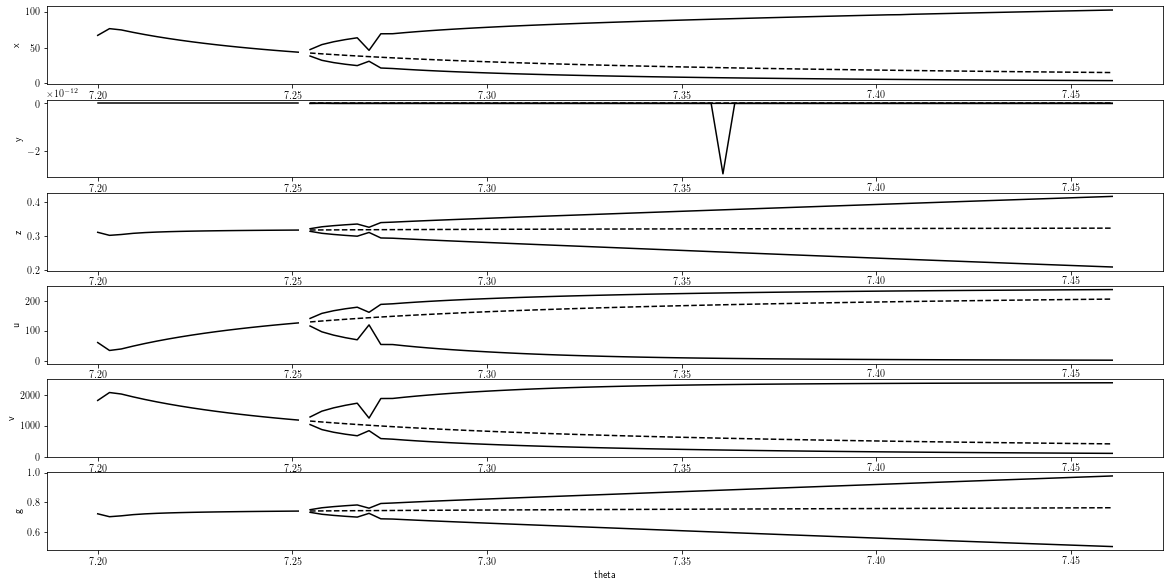

In [ ]:
plt.figure(figsize=(20,10))
labels = ['x', 'y', 'z', 'u', 'v', 'g']

stable_ss = np.array(stable_ss)
stable_theta = np.array(stable_theta)

unstable_ss = np.array(unstable_ss)
unstable_theta = np.array(unstable_theta)

max_vals = np.array(max_vals)
min_vals = np.array(min_vals)


for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    plt.plot(stable_theta, stable_ss[:,i], 'k-')
    plt.plot(unstable_theta, unstable_ss[:,i], 'k--')
    plt.plot(unstable_theta, max_vals[:,i], 'k-')
    plt.plot(unstable_theta, min_vals[:,i], 'k-')
    plt.ylabel(labels[i])
plt.xlabel(r'theta')

In [ ]:
# from PartialObservations.BandFModel import helper_fun

# sf = np.linspace(1.5,2.5,70)
# t = 0
# zero_sol = np.array([ 4.86695445e+001, 2.96340910e-128,  3.17491713e-001,  1.13238580e+002,
#   1.32088235e+003,  7.36691895e-001])
# output = zero_sol.copy()

# stable_ss = []
# stable_sf = []

# unstable_ss = []
# unstable_sf = []

# max_vals = []
# min_vals = []

# nan_arr = np.zeros(6)
# nan_arr[:] = np.nan

# switch = 0

# stable = True

# for i in range(len(sf)):
#     print('sf')
#     print(sf[i])
#     mypar = par_fun(D=1/7.3, sf=sf[i])
#     stable, zero_sol, output, T_period =  helper_fun.periodic_sol(ode_fun, 
#     torch_ode_fun, mypar, zero_sol, output, Tguess=200, coord=4)

#     # print('done')
#     if stable:
#         # print('STABLE!')
#         # print(zero_sol)
#         if switch == 1:
#             stable_ss.append(nan_arr.copy())
#             stable_sf.append(np.nan)
#             switch = 0
#         stable_ss.append(zero_sol)
#         stable_sf.append(sf[i])
#     else:
#         # print('UNSTABLE')
#         if switch == 0:
#             unstable_ss.append(nan_arr.copy())
#             unstable_sf.append(np.nan)
#             max_vals.append(nan_arr.copy())
#             min_vals.append(nan_arr.copy())
#             switch = 1
#         unstable_ss.append(zero_sol)
#         unstable_sf.append(sf[i])

#         tspan = [0,T_period]
#         tspan = [0,10000]

#         teval = np.linspace(tspan[0],tspan[1],10000)
        
#         sol = solve_ivp(ode_fun,tspan, output, t_eval=teval, args=(mypar,), rtol=1e-5, atol=1e-8)
#         max_vals.append(np.max(sol.y, axis=1))
#         min_vals.append(np.min(sol.y, axis=1))

#         labels = ['x', 'y', 'z', 'u', 'v', 'g']

#         # plt.figure(figsize=(20,10))

#         # for i in range(6):
#         #     plt.subplot(int(str(61) + str(i+1)))
#         #     plt.plot(sol.t, sol.y[i,:])
#         #     plt.ylabel(labels[i])
#         # plt.xlabel(r'theta')
#         # assert False
# # import helper_fun

(0.201450443190975, 250.0, 9.7, 10.0, 0.1313868613138686, 1.2916666666666667, 0.29411764705882354, 0.3676470588235294, 0.3676470588235294, 0.11764705882352941, 0.16176470588235292)
[8.79260375e+01 2.36384378e-12 3.58187968e-02 1.60596660e+00
 2.40878041e+03 8.28881253e-02]


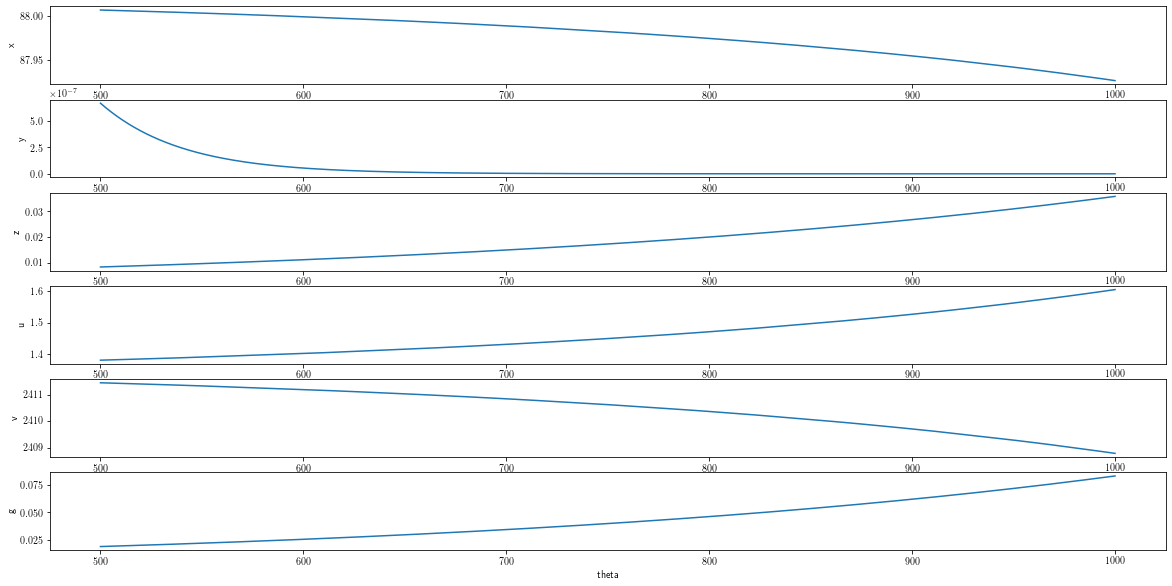

In [4]:
mypar = par_fun(D=1/7.3, sf=2.5)
t = 0

print(mypar)

# myvar0 = np.array([2.45524443e+01, 9.40042585e-11, 1.94133806e-01, 1.96344728e+02,
#  5.16882041e+02, 4.61654478e-01])
myvar0 = [7.54651217e+001, 5.68061229e-110, 3.16832990e-001, 3.07716331e+001,
 2.12083688e+003, 7.33444520e-001]

myvar0 = [7.83577452e+01, 1.76910142e-01, 1.21884731e-02, 1.24296145e+00,
 2.41269019e+03, 3.27558469e-02]

myvar0 = np.concatenate((np.random.uniform(0.01,100,1),
                         np.random.uniform(0.01,1.5,1),
                         np.random.uniform(0.01,1.5,1),
                         np.random.uniform(0.01,250,1),
                         np.random.uniform(0.01,2200,1),
                         np.random.uniform(0.01,4.5,1)))

# zero_sol = fsolve(lambda y, par: ode_fun(0,y,par), myvar0, args=(mypar,))
# print(zero_sol)

tspan = [0,500]
tskip = 500

sol = solve_ivp(ode_fun, y0=myvar0, 
                t_span=[tspan[0],tspan[1]+tskip], t_eval=np.linspace(tskip,tspan[1]+tskip,1000), args=(mypar,), 
                rtol=1e-5, atol=1e-8)

labels = ['x', 'y', 'z', 'u', 'v', 'g']

print(sol.y[:,-1])

plt.figure(figsize=(20,10))

for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    plt.plot(sol.t, sol.y[i,:])
    plt.ylabel(labels[i])
plt.xlabel(r'theta')
plt.show()



In [ ]:
print(sol.y[:,-1])

stable, zero_sol, output, T_period =  helper_fun.periodic_sol(ode_fun, 
    torch_ode_fun, mypar, sol.y[:,-1], sol.y[:,-1], Tguess=220, coord=4)


[2.25304731e+01 8.40219033e-20 5.75249829e-01 1.46386107e+02
 9.94721015e+02 1.33477520e+00]
zero_sol
[4.03795735e+00 1.04511937e-23 3.35376734e-01 2.37542902e+02
 1.14403341e+02 8.30607994e-01]
0.1
-0.08000000000000002
0.06400000000000002
-0.051200000000000016
0.04096000000000002
-0.03276800000000001
0.026214400000000013
-0.02097152000000001
0.016777216000000008
-0.013421772800000007
0.010737418240000006
-0.008589934592000005
0.0068719476736000045
-0.005497558138880004
0.004398046511104004
-0.0035184372088832034
0.002814749767106563
-0.0022517998136852503
0.0018014398509482003


KeyboardInterrupt: 

In [ ]:
print(output)

[4.04883664e+01 5.25111710e-05 3.17881920e-01 1.36239225e+02
 1.20439018e+03 7.38512234e-01]


In [ ]:
tspan = [0,T_period]
tspan = [0,10000]
mypar = par_fun(D=1/7.253853853853854, sf=2.5)
teval = np.linspace(tspan[0],tspan[1],10000)
sol = solve_ivp(ode_fun,tspan, output, args=(mypar,), rtol=1e-5, atol=1e-8)

labels = ['x', 'y', 'z', 'u', 'v', 'g']

plt.figure(figsize=(20,10))

for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    plt.plot(sol.t, sol.y[i,:])
    plt.ylabel(labels[i])
plt.xlabel(r'theta')

tspan = [0,T_period]
# tspan = [0,10000]

mypar = par_fun(D=1/7.2545, sf=2.5)
teval = np.linspace(tspan[0],tspan[1],10000)
sol = solve_ivp(ode_fun,tspan, output, args=(mypar,), rtol=1e-5, atol=1e-8)

labels = ['x', 'y', 'z', 'u', 'v', 'g']

plt.figure(figsize=(20,10))

for i in range(6):
    plt.subplot(int(str(61) + str(i+1)))
    plt.plot(sol.t, sol.y[i,:])
    plt.ylabel(labels[i])
plt.xlabel(r'theta')

NameError: name 'output' is not defined